In [ ]:
!pip install pandas numpy scikit-learn nltk spacy pdfminer.six sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 48.4 MB/s eta 0:00:00


In [ ]:
!pip install python-docx

In [ ]:
import os
import kagglehub
from docx import Document
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

In [ ]:
dataset_path = kagglehub.dataset_download("palaksood97/resume-dataset")
print("Dataset downloaded at:", dataset_path)

Using Colab cache for faster access to the 'resume-dataset' dataset.
Dataset downloaded at: /kaggle/input/resume-dataset


In [ ]:
docx_files = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(".docx"):
            docx_files.append(os.path.join(root, file))

print(f"Found {len(docx_files)} DOCX files.")

Found 228 DOCX files.


In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def extract_text(file_path):
    """Extract all text from a DOCX file."""
    doc = Document(file_path)
    return "\n".join([p.text for p in doc.paragraphs])

def preprocess_text(text):
    """Lowercase, remove punctuation, tokenize, remove stopwords."""
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    filtered = [w for w in tokens if w not in stop_words]
    return filtered

def extract_skills(tokens, skills_list):
    """Extract matched skills from tokens."""
    return [skill for skill in skills_list if skill in tokens]

In [ ]:
job_description = """
Looking for a Business Analyst with experience in SQL, Python, Agile methodologies, and Data Analysis.
"""

In [ ]:
skills_list = ["python", "sql", "java", "agile", "data", "machine",
               "excel", "project", "management", "html", "css", "javascript"]

In [ ]:

candidate_texts = []
candidate_names = []
candidate_skills = []

for file_path in docx_files:
    name = os.path.basename(file_path)
    candidate_names.append(name)

    text = extract_text(file_path)
    tokens = preprocess_text(text)
    candidate_texts.append(" ".join(tokens))

    skills_found = extract_skills(tokens, skills_list)
    candidate_skills.append(skills_found)

In [ ]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(candidate_texts)
job_vector = vectorizer.transform([job_description.lower()])
tfidf_scores = cosine_similarity(X, job_vector).flatten()

In [ ]:
weighted_scores = []
jd_skills = [skill for skill in skills_list if skill in job_description.lower().split()]

for i, skills in enumerate(candidate_skills):
    if len(jd_skills) > 0:
        skill_match_ratio = len(set(skills).intersection(set(jd_skills))) / len(jd_skills)
    else:
        skill_match_ratio = 0
    # Weighted: 70% TF-IDF + 30% skill match
    weighted_score = 0.7 * tfidf_scores[i] + 0.3 * skill_match_ratio
    weighted_scores.append(weighted_score)

In [ ]:
ranking = list(zip(candidate_names, weighted_scores, candidate_skills))
ranking.sort(key=lambda x: x[1], reverse=True)

In [ ]:
print("\nTop 10 Candidates:\n")
for name, score, skills in ranking[:10]:
    print(f"{name} => Score: {round(score, 3)}, Skills matched: {skills}")


Top 10 Candidates:

Bharatha BA Resume.docx => Score: 0.375, Skills matched: ['sql', 'agile', 'data', 'project', 'management']
Shashank.docx => Score: 0.372, Skills matched: ['sql', 'agile', 'data', 'excel', 'project', 'management']
RAMYA BUSINESS ANALYST RESUME.docx => Score: 0.368, Skills matched: ['sql', 'java', 'agile', 'data', 'excel', 'project', 'management', 'html', 'css', 'javascript']
Sahas BA Resume.docx => Score: 0.368, Skills matched: ['sql', 'agile', 'data', 'excel', 'project', 'management']
Madhu_BA_AW.DOCX => Score: 0.366, Skills matched: ['sql', 'java', 'agile', 'data', 'excel', 'project', 'management', 'html']
Pankaj BSA.docx => Score: 0.366, Skills matched: ['sql', 'java', 'agile', 'data', 'excel', 'project', 'management', 'html', 'css', 'javascript']
Yohan BSA.docx => Score: 0.366, Skills matched: ['sql', 'agile', 'data', 'excel', 'project', 'management', 'html']
Vijay Bhargav.docx => Score: 0.365, Skills matched: ['python', 'sql', 'java', 'agile', 'data', 'machine'

In [ ]:
df = pd.DataFrame(ranking, columns=["Candidate", "WeightedScore", "SkillsMatched"])
df.to_csv("top_candidates.csv", index=False)
print("\nTop candidates saved to 'top_candidates.csv'")


Top candidates saved to 'top_candidates.csv'


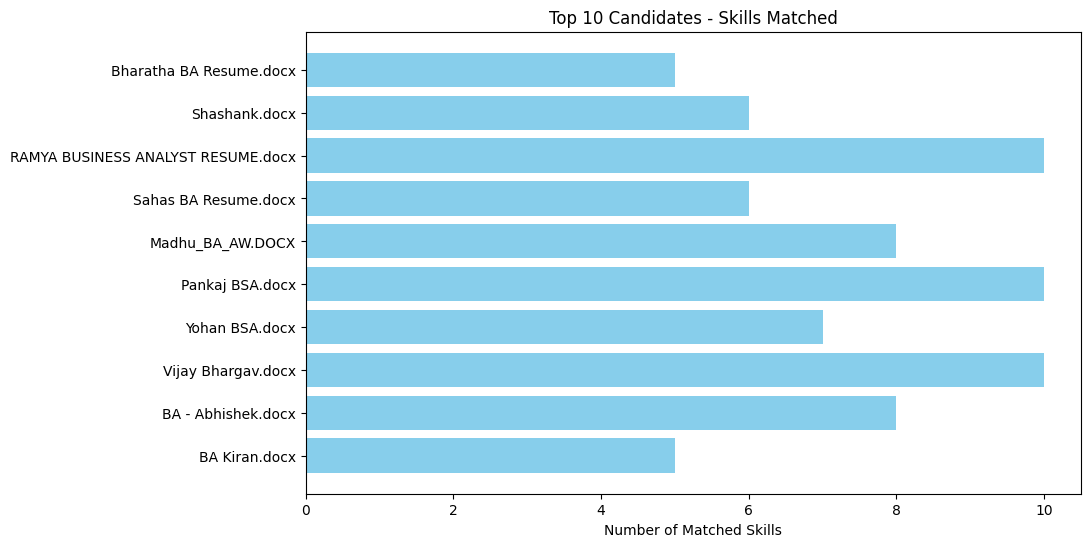

In [ ]:
import matplotlib.pyplot as plt

top_candidates = ranking[:10]
names = [c[0] for c in top_candidates]
skills_count = [len(c[2]) for c in top_candidates]

plt.figure(figsize=(10,6))
plt.barh(names, skills_count, color='skyblue')
plt.xlabel("Number of Matched Skills")
plt.title("Top 10 Candidates - Skills Matched")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
from joblib import dump

# Save TF-IDF vectorizer
dump(vectorizer, "resume_vectorizer.joblib")
print("Vectorizer saved as 'resume_vectorizer.joblib'")

Vectorizer saved as 'resume_vectorizer.joblib'
